In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import boxcox, boxcox_normmax, boxcox_llf, shapiro, kstest
from scipy.optimize import minimize_scalar

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv('dataset_foodpriceindex.csv')
df

,id,Country,Year,Month,FoodPriceIndex
0,3501,Mexico,1971,11,0.0000
1,60601,South Africa,2002,7,43.9000
2,64399,Japan,2004,8,89.8000
3,24227,France,1983,1,48.9000
4,63779,Japan,2004,4,90.2000
...,...,...,...,...,...
11611,8347,Sweden,1974,6,17.9000
11612,32121,Germany,1987,4,66.1407
11613,8561,Germany,1974,8,45.1606
11614,45917,Denmark,1994,9,65.6000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11616 entries, 0 to 11615
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              11616 non-null  int64  
 1   Country         11616 non-null  object 
 2   Year            11616 non-null  int64  
 3   Month           11616 non-null  int64  
 4   FoodPriceIndex  11268 non-null  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 453.9+ KB


In [5]:
country = "United States"
df_country = df[df["Country"] == country].copy()

In [6]:
df_country["Date"] = pd.to_datetime(
    df_country[["Year", "Month"]].assign(DAY=1)
)
df_country = df_country.sort_values("Date")

In [7]:
df_country["FoodPriceIndex"] = df_country["FoodPriceIndex"].interpolate()

In [8]:
ts = df_country["FoodPriceIndex"]

In [9]:
df_country.describe()

,id,Year,Month,FoodPriceIndex,Date
count,528.000000,528.000000,528.000000,528.000000,528
mean,40988.500000,1991.500000,6.500000,55.256155,1991-12-16 11:00:00
min,146.000000,1970.000000,1.000000,16.300000,1970-01-01 00:00:00
25%,20567.250000,1980.750000,3.750000,38.350000,1980-12-24 06:00:00
50%,40988.500000,1991.500000,6.500000,56.150000,1991-12-16 12:00:00
75%,61409.750000,2002.250000,9.250000,72.650000,2002-12-08 18:00:00
max,81831.000000,2013.000000,12.000000,96.400000,2013-12-01 00:00:00
std,23647.534755,12.710467,3.455326,23.313661,NaN


# Plot Data Deret Waktu

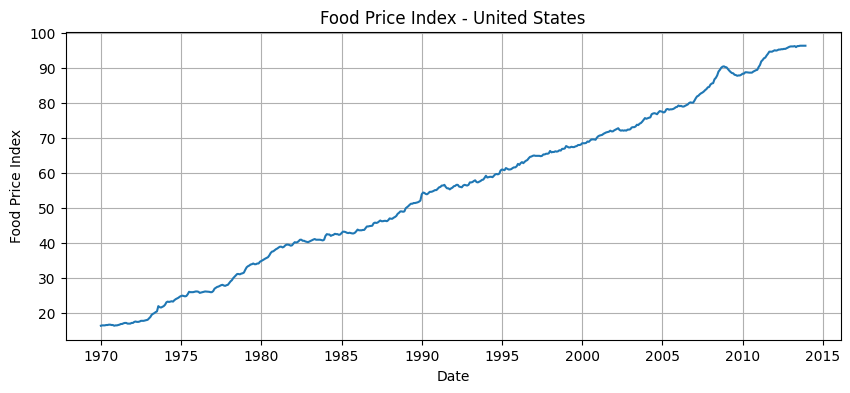

In [10]:
plt.figure(figsize=(10,4))
plt.plot(df_country["Date"], ts)
plt.title(f"Food Price Index - {country}")
plt.xlabel("Date")
plt.ylabel("Food Price Index")
plt.grid(True)
plt.show()

# Uji Kestasioner Variansi - Box-Cox

## Estimasi Lambda Optimal (MLE)

In [11]:
lambda_est = boxcox_normmax(ts, method='mle')

##Confidence Interval 95% untuk Lambda

In [12]:
def neg_llf(lmbda, ts):
    return -boxcox_llf(lmbda, ts)

res = minimize_scalar(neg_llf, bounds=(-5, 5), args=(ts,), method='bounded')

llf_max = -res.fun
crit = llf_max - 0.5 * 3.84   # chi-square 95%

## Box-Cox Plot (Std Dev vs Lambda)

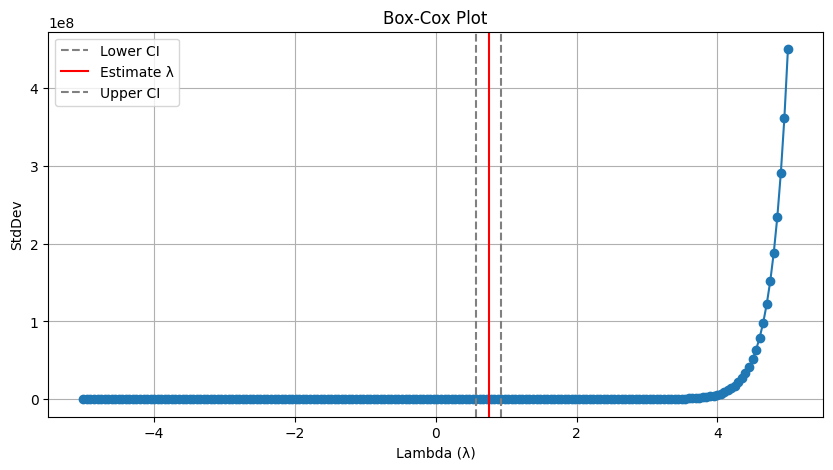

Estimasi λ = 0.7509
Lower CI   = 0.5779
Upper CI   = 0.9296
Rounded λ  = 0.8


In [13]:
lambdas = np.linspace(-5, 5, 200)
llf_vals = [boxcox_llf(l, ts) for l in lambdas]

ci = lambdas[np.where(llf_vals >= crit)]
lower_ci = ci.min()
upper_ci = ci.max()

std_vals = []

for l in lambdas:
    transformed = (ts**l - 1) / l if l != 0 else np.log(ts)
    std_vals.append(np.std(transformed))

plt.figure(figsize=(10,5))
plt.plot(lambdas, std_vals, marker='o')
plt.title("Box-Cox Plot")
plt.xlabel("Lambda (λ)")
plt.ylabel("StdDev")

plt.axvline(lower_ci, color='gray', linestyle='--', label='Lower CI')
plt.axvline(lambda_est, color='red', linestyle='-', label='Estimate λ')
plt.axvline(upper_ci, color='gray', linestyle='--', label='Upper CI')

plt.legend()
plt.grid(True)
plt.show()

print("Estimasi λ =", round(lambda_est, 4))
print("Lower CI   =", round(lower_ci, 4))
print("Upper CI   =", round(upper_ci, 4))

rounded_val = round(lambda_est, 1)
print("Rounded λ  =", rounded_val)

# Transformasi

In [14]:
lambda_used = lambda_est   # ← PAKAI λ ESTIMASI

if lambda_used == 0:
    ts_bc = np.log(ts)
else:
    ts_bc = (ts ** lambda_used - 1) / lambda_used

ts_bc = pd.Series(ts_bc, index=ts.index)

## Plot Data

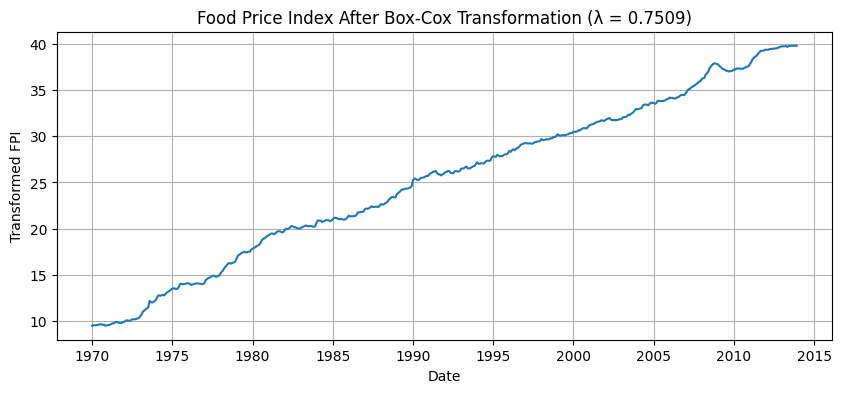

In [15]:
plt.figure(figsize=(10,4))
plt.plot(df_country["Date"], ts_bc)
plt.title(f"Food Price Index After Box-Cox Transformation (λ = {lambda_used:.4f})")
plt.xlabel("Date")
plt.ylabel("Transformed FPI")
plt.grid(True)
plt.show()

In [16]:
print("Std Dev sebelum transformasi :", np.std(ts))
print("Std Dev sesudah transformasi :", np.std(ts_bc))

Std Dev sebelum transformasi : 23.291573098678132
Std Dev sesudah transformasi : 8.753426978129086


## Cek Ulang Kestasioneran Variansi

In [17]:
# Estimasi lambda ulang
lambda_recheck = boxcox_normmax(ts_bc, method='mle')

# CI 95%
def neg_llf_re(lmbda):
    return -boxcox_llf(lmbda, ts_bc)

res_re = minimize_scalar(
    neg_llf_re,
    bounds=(-5, 5),
    method='bounded'
)

llf_max_re = -res_re.fun
crit_re = llf_max_re - 0.5 * 3.84

lambdas = np.linspace(-5, 5, 200)
llf_vals_re = [boxcox_llf(l, ts_bc) for l in lambdas]

ci_re = lambdas[np.where(llf_vals_re >= crit_re)]
lower_ci_re = ci_re.min()
upper_ci_re = ci_re.max()

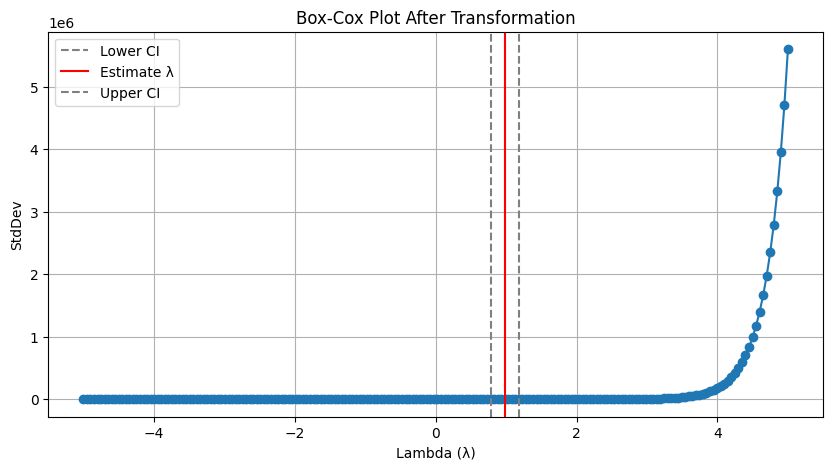

In [18]:
std_vals_re = []

for l in lambdas:
    if l == 0:
        transformed = np.log(ts_bc)
    else:
        transformed = (ts_bc**l - 1) / l
    std_vals_re.append(np.std(transformed))

plt.figure(figsize=(10,5))
plt.plot(lambdas, std_vals_re, marker='o')
plt.axvline(lower_ci_re, color='gray', linestyle='--', label='Lower CI')
plt.axvline(lambda_recheck, color='red', linestyle='-', label='Estimate λ')
plt.axvline(upper_ci_re, color='gray', linestyle='--', label='Upper CI')

plt.title("Box-Cox Plot After Transformation")
plt.xlabel("Lambda (λ)")
plt.ylabel("StdDev")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
print("Estimasi λ setelah transformasi :", round(lambda_recheck, 4))
print("Lower CI 95%                  :", round(lower_ci_re, 4))
print("Upper CI 95%                  :", round(upper_ci_re, 4))

if lower_ci_re <= 1 <= upper_ci_re:
    print("KESIMPULAN: Data SUDAH stasioner terhadap variansi")
else:
    print("KESIMPULAN: Data BELUM stasioner terhadap variansi")

Estimasi λ setelah transformasi : 0.9854
Lower CI 95%                  : 0.7789
Upper CI 95%                  : 1.1809
KESIMPULAN: Data SUDAH stasioner terhadap variansi


# Uji Kestasioner Mean – ADF

In [20]:
ts_adf = ts_bc.replace([np.inf, -np.inf], np.nan).dropna()

In [21]:
def print_adf_result(result, title="ADF Test"):
    print(f"===== {title} =====")
    print(f"ADF Statistic     : {result[0]}")
    print(f"p-value           : {result[1]}")
    print(f"Used Lags         : {result[2]}")
    print(f"Number of Obs     : {result[3]}")
    print("Critical Values   :")
    for key, value in result[4].items():
        print(f"   {key}: {value}")

In [22]:
result_bc = adfuller(ts_adf)
print_adf_result(result_bc, title="ADF Test")

===== ADF Test =====
ADF Statistic     : -1.234279130793284
p-value           : 0.6586786643766775
Used Lags         : 14
Number of Obs     : 513
Critical Values   :
   1%: -3.443161545965353
   5%: -2.8671904981615706
   10%: -2.5697795041589244


# Differencing (Trend)

In [23]:
d = 0
ts_diff = ts_adf.copy()

if result_bc[1] < 0.05:
    print("Data sudah stasioner terhadap mean (d = 0)")
else:
    print("Data belum stasioner terhadap mean, lakukan differencing...\n")

    while d < 2:
        d += 1
        ts_diff = ts_diff.diff().dropna()
        result_d = adfuller(ts_diff)

        print_adf_result(result_d, title=f"ADF Test After Differencing d = {d}")

        if result_d[1] < 0.05:
            print(f"Data menjadi stasioner terhadap mean pada differencing ke-{d}")
            break

if d == 2 and result_d[1] >= 0.05:
    print("PERINGATAN: Data belum stasioner meskipun sudah differencing maksimum.")

Data belum stasioner terhadap mean, lakukan differencing...

===== ADF Test After Differencing d = 1 =====
ADF Statistic     : -5.390780833494051
p-value           : 3.5415432025565533e-06
Used Lags         : 13
Number of Obs     : 513
Critical Values   :
   1%: -3.443161545965353
   5%: -2.8671904981615706
   10%: -2.5697795041589244
Data menjadi stasioner terhadap mean pada differencing ke-1


## Plot Setelah Differencing

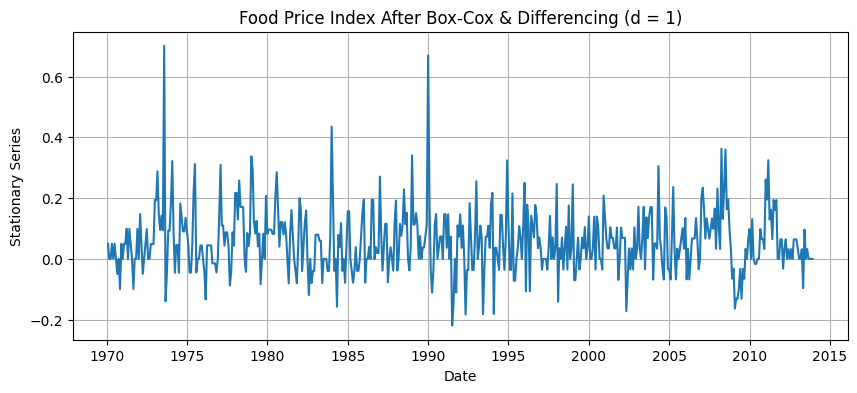

In [24]:
plt.figure(figsize=(10,4))
plt.plot(df_country["Date"].iloc[d:], ts_diff)
plt.title(f"Food Price Index After Box-Cox & Differencing (d = {d})")
plt.xlabel("Date")
plt.ylabel("Stationary Series")
plt.grid(True)
plt.show()

# Plot ACF & PACF

In [25]:
# Data final untuk ACF & PACF
ts_final = ts_diff.copy()

<Figure size 1000x400 with 0 Axes>

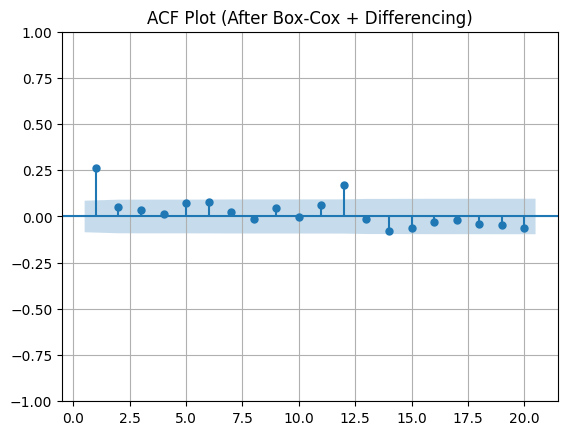

In [26]:
plt.figure(figsize=(10,4))
plot_acf(ts_final, lags=20, zero=False)
plt.title("ACF Plot (After Box-Cox + Differencing)")
plt.grid(True)
plt.show()

<Figure size 1000x400 with 0 Axes>

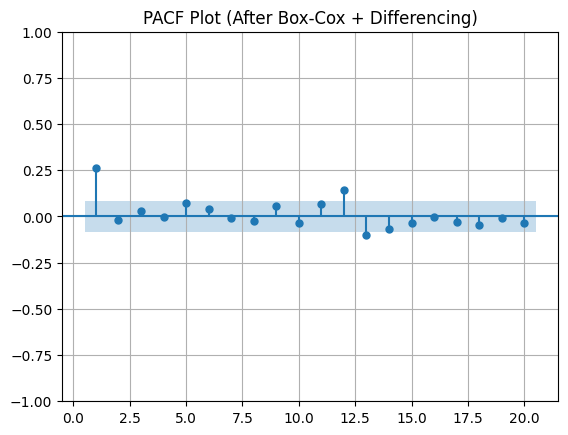

In [27]:
plt.figure(figsize=(10,4))
plot_pacf(ts_final, lags=20, zero=False, method='ywm')
plt.title("PACF Plot (After Box-Cox + Differencing)")
plt.grid(True)
plt.show()

# Hitung nilai ACF & PACF + batas signifikansi

In [28]:
acf_vals = acf(ts_final, nlags=20, fft=False)
pacf_vals = pacf(ts_final, nlags=20, method='ywm')

n = len(ts_final)
conf = 1.96 / np.sqrt(n)

print("Batas Signifikansi (±):", conf)

print("\nACF Values:")
for i, v in enumerate(acf_vals):
    print(f"Lag {i}: {v:.4f}")

print("\nPACF Values:")
for i, v in enumerate(pacf_vals):
    print(f"Lag {i}: {v:.4f}")

Batas Signifikansi (±): 0.08537894100633028

ACF Values:
Lag 0: 1.0000
Lag 1: 0.2602
Lag 2: 0.0519
Lag 3: 0.0351
Lag 4: 0.0140
Lag 5: 0.0735
Lag 6: 0.0779
Lag 7: 0.0250
Lag 8: -0.0129
Lag 9: 0.0461
Lag 10: -0.0037
Lag 11: 0.0623
Lag 12: 0.1710
Lag 13: -0.0126
Lag 14: -0.0760
Lag 15: -0.0642
Lag 16: -0.0311
Lag 17: -0.0197
Lag 18: -0.0395
Lag 19: -0.0448
Lag 20: -0.0646

PACF Values:
Lag 0: 1.0000
Lag 1: 0.2602
Lag 2: -0.0169
Lag 3: 0.0276
Lag 4: -0.0013
Lag 5: 0.0747
Lag 6: 0.0426
Lag 7: -0.0082
Lag 8: -0.0235
Lag 9: 0.0574
Lag 10: -0.0361
Lag 11: 0.0700
Lag 12: 0.1428
Lag 13: -0.0994
Lag 14: -0.0653
Lag 15: -0.0377
Lag 16: -0.0041
Lag 17: -0.0323
Lag 18: -0.0455
Lag 19: -0.0056
Lag 20: -0.0361


# Identifikasi lag signifikan

In [29]:
acf_significant = [i for i, v in enumerate(acf_vals) if abs(v) > conf]
pacf_significant = [i for i, v in enumerate(pacf_vals) if abs(v) > conf]

print("Lag signifikan ACF :", acf_significant)
print("Lag signifikan PACF:", pacf_significant)

Lag signifikan ACF : [0, 1, 12]
Lag signifikan PACF: [0, 1, 12, 13]


# Pemilihan Model Terbaik Berdasarkan AIC

In [30]:
candidate_models = [
    (0,1,1),
    (0,1,12),
    (1,1,0),
    (1,1,1),
    (1,1,12),
    (12,1,0),
    (12,1,1),
    (12,1,12),
    (13,1,0),
    (13,1,1),
    (13,1,12)
]

aic_results = []

for order in candidate_models:
    try:
        model = ARIMA(ts_bc, order=order)
        result = model.fit()
        aic_results.append({
            "Model": f"ARIMA{order}",
            "AIC": result.aic
        })
        print(f"ARIMA{order} fitted | AIC = {result.aic:.2f}")
    except Exception as e:
        print(f"ARIMA{order} gagal:", e)

ARIMA(0, 1, 1) fitted | AIC = -835.69
ARIMA(0, 1, 12) fitted | AIC = -893.40
ARIMA(1, 1, 0) fitted | AIC = -860.32
ARIMA(1, 1, 1) fitted | AIC = -891.01
ARIMA(1, 1, 12) fitted | AIC = -897.81
ARIMA(12, 1, 0) fitted | AIC = -911.82
ARIMA(12, 1, 1) fitted | AIC = -911.49
ARIMA(12, 1, 12) fitted | AIC = -905.49
ARIMA(13, 1, 0) fitted | AIC = -912.06
ARIMA(13, 1, 1) fitted | AIC = -910.26
ARIMA(13, 1, 12) fitted | AIC = -917.50


In [31]:
aic_df = pd.DataFrame(aic_results).sort_values("AIC")
aic_df

,Model,AIC
10,"ARIMA(13, 1, 12)",-917.495224
8,"ARIMA(13, 1, 0)",-912.061437
5,"ARIMA(12, 1, 0)",-911.818363
6,"ARIMA(12, 1, 1)",-911.489005
9,"ARIMA(13, 1, 1)",-910.255670
7,"ARIMA(12, 1, 12)",-905.488757
4,"ARIMA(1, 1, 12)",-897.811741
1,"ARIMA(0, 1, 12)",-893.396474
3,"ARIMA(1, 1, 1)",-891.011446
2,"ARIMA(1, 1, 0)",-860.319434


In [32]:
best_model_order = tuple(
    map(int, aic_df.iloc[0]["Model"].replace("ARIMA","").strip("()").split(","))
)

print("Model ARIMA terbaik berdasarkan AIC:", best_model_order)

Model ARIMA terbaik berdasarkan AIC: (13, 1, 12)


# Estimasi Parameter (MLE) & Uji Signifikansi

In [33]:
best_model = ARIMA(ts_bc, order=(13,1,12))
best_result = best_model.fit()

print(best_result.summary())

                               SARIMAX Results                                
Dep. Variable:         FoodPriceIndex   No. Observations:                  528
Model:               ARIMA(13, 1, 12)   Log Likelihood                 484.748
Date:                Mon, 02 Mar 2026   AIC                           -917.495
Time:                        02:01:07   BIC                           -806.548
Sample:                             0   HQIC                          -874.058
                                - 528                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2411      0.329      0.733      0.463      -0.403       0.886
ar.L2         -0.0925      0.268     -0.345      0.730      -0.618       0.433
ar.L3         -0.2492      0.249     -1.000      0.3

# Uji Kelayakan Model (Ljung–Box)

In [34]:
residuals = best_result.resid

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10, 20],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
10,0.113438,1.0
20,0.346311,1.0


# Uji Kenormalan Sisaan

In [35]:
residuals = best_result.resid.dropna()

In [36]:
resid_std = (residuals - residuals.mean()) / residuals.std()

ks_stat, ks_p = kstest(resid_std, 'norm')

print("KS Statistic :", ks_stat)
print("KS p-value   :", ks_p)

if ks_p > 0.05:
    print("KESIMPULAN: Residual NORMAL (KS Test)")
else:
    print("KESIMPULAN: Residual TIDAK NORMAL (KS Test)")

KS Statistic : 0.3231625319300252
KS p-value   : 1.4205599038074085e-49
KESIMPULAN: Residual TIDAK NORMAL (KS Test)


# Forecasting + RMSE

In [37]:
order_best = (13, 1, 12)
lambda_used = float(lambda_est)

ts_bc = pd.Series(ts_bc).astype(float).dropna()

n = len(ts_bc)
train_size = int(0.8 * n)

ts_train = ts_bc.iloc[:train_size]
ts_test  = ts_bc.iloc[train_size:]

print("Train size:", len(ts_train))
print("Test size :", len(ts_test))
print("Order ARIMA:", order_best)

Train size: 422
Test size : 106
Order ARIMA: (13, 1, 12)


In [38]:
model = ARIMA(
    ts_train,
    order=order_best,
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = model.fit()

In [39]:
# Mengurutkan Date
ts_bc_series = pd.Series(ts_bc.values, index=df_country["Date"]).sort_index()
n = len(ts_bc_series)
train_size = int(0.8 * n)
ts_train = ts_bc_series.iloc[:train_size]
ts_test  = ts_bc_series.iloc[train_size:]

In [40]:
lambda_used = float(lambda_est)

# Forecast
pred = res.get_forecast(steps=len(ts_test))
forecast_bc = pd.Series(pred.predicted_mean.values, index=ts_test.index).astype(float)

In [41]:
def inv_boxcox(y, lmbda, eps=1e-8):
    y = pd.Series(y).astype(float)
    if lmbda == 0:
        return np.exp(y)
    base = lmbda * y + 1
    base = np.maximum(base, eps)
    return pd.Series(np.power(base, 1.0 / lmbda), index=y.index)

forecast_orig = inv_boxcox(forecast_bc, lambda_used)
actual_orig   = inv_boxcox(ts_test, lambda_used)


In [42]:
rmse = np.sqrt(mean_squared_error(actual_orig, forecast_orig))

print("RMSE (skala asli):", rmse)

RMSE (skala asli): 4.910401284081156


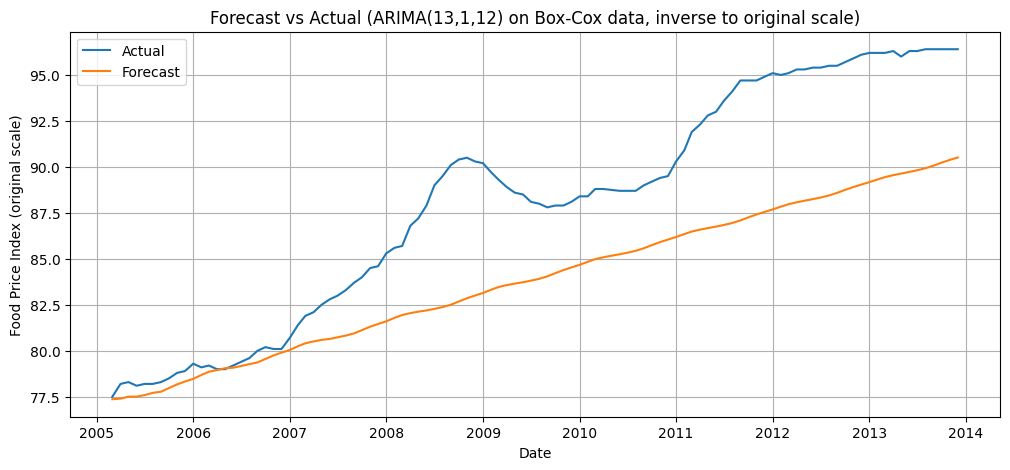

In [43]:
plt.figure(figsize=(12,5))
plt.plot(actual_orig.index, actual_orig, label="Actual", linewidth=1.5)
plt.plot(forecast_orig.index, forecast_orig, label="Forecast", linewidth=1.5)
plt.title("Forecast vs Actual (ARIMA(13,1,12) on Box-Cox data, inverse to original scale)")
plt.xlabel("Date")
plt.ylabel("Food Price Index (original scale)")
plt.legend()
plt.grid(True)
plt.show()